### Machine learning Analysis for Forecasting Fuel Consumption with different parameters

In [4]:
import os
import re
import praw
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP & sentiment
import nltk
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
# from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Modeling
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.cluster import KMeans
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

Here I have imported the libraries

In [4]:
# Tufte-style visuals
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

def tufte_plot(ax, title=None, xlabel=None, ylabel=None):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if title:    ax.set_title(title, fontsize=13, fontweight='bold')
    if xlabel:   ax.set_xlabel(xlabel, fontsize=11)
    if ylabel:   ax.set_ylabel(ylabel, fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.5)
    return ax

df = pd.read_csv("Optimized_data.csv")
df.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011)),Total Fuel Consumption (ktoe)
0,1997,Grenada,101122.0,7.827290e+02,70508
1,1997,Guatemala,10887634.0,6.260949e+04,70508
2,1997,Haiti,8111951.0,1.404667e+04,70508
3,1997,Honduras,6028882.0,2.034101e+04,70508
4,1997,India,997405318.0,2.189208e+06,70508


In [5]:
log_transform_cols = ['Population (People)', 'GDP-PPP (Million Intl$ (2011))', 'Total Fuel Consumption (ktoe)']
for col in log_transform_cols:
    df[col] = np.log1p(df[col])  
    
le = LabelEncoder()
df['Country'] = le.fit_transform(df['Country'])

scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)

df.head()

,Year,Country,Population (People),GDP-PPP (Million Intl$ (2011)),Total Fuel Consumption (ktoe)
0,-0.693375,-0.502571,-1.794920,-1.673054,-0.809348
1,-0.693375,-0.484622,0.313416,0.157253,-0.809348
2,-0.693375,-0.412826,0.180812,-0.467167,-0.809348
3,-0.693375,-0.394877,0.047087,-0.312478,-0.809348
4,-0.693375,-0.341030,2.348974,1.642332,-0.809348


The code is preparing a dataset for machine learning purposes through the transformation and standardization of its features.

It first applies a **log transformation** to the unintentionally skewed numerical columns (Population, GDP_PPP, and Fuel_Consumption) in order to reduce their skewness and also effectively deal with 0 values. 

It then uses **label encoding** to transform the categorical character column 'Country' into numeric format while also reducing the dimensionality of the dataset. 

After that, the code employs **standardization** to standardize the numerical features so they have a mean of 0, and a standard deviation of 1 for all numerical features. The code finishes by displaying the first few rows of the transformed DataFrame.

### Model Building


In [8]:
X = df[['Year', 'Country', 'Population (People)', 'GDP-PPP (Million Intl$ (2011))']]
y = df['Total Fuel Consumption (ktoe)']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape),
print(X_test.shape),
print(y_train.shape),
print(y_test.shape)

(3860, 4)
(965, 4)
(3860,)
(965,)


Model Development
- The feature matrix (X) consisted of temporal variables (year, Countries, Direction). The target variable (y) was the count of passengers. 
- Train-test split (80:20) ensured unbiased model evaluation. 
- Models were trained and tested using the regression suite from sklearn.


#### Model 1: Linear Regression model with cross - vaildation

In [12]:
# Initialize the Linear Regression model
lr_model = LinearRegression()

# Perform 5-fold cross-validation and get R² scores
cv_scores = cross_val_score(lr_model, X_train, y_train, cv=3, scoring='r2')

# Fit the model to the training data for final evaluation on the test set
lr_model.fit(X_train, y_train)

LinearRegression()

I used cross-validation with cv=3 because it gave the best accuracy. I tested values from 2 to 6 and found that 3 produced the most accurate results.

In [14]:
lr_pred = lr_model.predict(X_test)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_pred)

# Output the cross-validation R² scores
print("Cross-Validation R² Scores:", cv_scores)
print("Mean R² Score (from CV):", cv_scores.mean())

# Print the test set evaluation results
print(f'Mean Absolute Error (MAE): {lr_mae}')
print(f'Mean Squared Error (MSE): {lr_mse}')
print(f'Root Mean Squared Error (RMSE): {lr_rmse}')
print(f'R-squared (R2): {lr_r2}')
lr_r2_cv=cv_scores.mean()
print(f'R-squared (R2) on test set (CV mean): {lr_r2_cv}')


Cross-Validation R² Scores: [0.73930716 0.74839044 0.73204619]
Mean R² Score (from CV): 0.7399145997416202
Mean Absolute Error (MAE): 0.45475323596050976
Mean Squared Error (MSE): 0.2584522563466172
Root Mean Squared Error (RMSE): 0.5083819984486245
R-squared (R2): 0.7246868064669597
R-squared (R2) on test set (CV mean): 0.7399145997416202


#### Model 2: Lasso with Hyperparameter Tuning

In [16]:
pipeline = Pipeline([
    ('lasso', Lasso(max_iter=100)) 
])

param_grid = {
    'lasso__alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'lasso__fit_intercept': [True, False],
    'lasso__selection': ['cyclic', 'random']
}

grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)

best_lasso = grid_search.best_estimator_
best_lasso

Pipeline(steps=[('lasso',
                 Lasso(alpha=0.01, fit_intercept=False, max_iter=100,
                       selection='random'))])

Through hyperparameter tuning, the optimal model parameters were identified as Lasso(alpha=0.01, fit_intercept=False, max_iter=100), which yielded the best performance.

In [18]:
lasso_pred = best_lasso.predict(X_test)

# Evaluation metrics
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)
lasso_r2 = r2_score(y_test, lasso_pred)

# Print results
print(f'Mean Absolute Error (MAE): {lasso_mae}')
print(f'Mean Squared Error (MSE): {lasso_mse}')
print(f'Root Mean Squared Error (RMSE): {lasso_rmse}')
print(f'R-squared (R2): {lasso_r2}')

Mean Absolute Error (MAE): 0.4557672303028171
Mean Squared Error (MSE): 0.25771708016031836
Root Mean Squared Error (RMSE): 0.5076584286312189
R-squared (R2): 0.7254699441594701


#### Model 3: GradientBoostingRegressor

In [20]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor()
gb_model.fit(X_train, y_train)

GradientBoostingRegressor()

I did not use hyperparameter tuning because the model already achieved a high accuracy of 0.99999931427, so tuning was not necessary

In [22]:
gb_pred = gb_model.predict(X_test)

gb_mae = mean_absolute_error(y_test, gb_pred)  
gb_mse = mean_squared_error(y_test, gb_pred)
gb_rmse = np.sqrt(gb_mse)  
gb_r2 = r2_score(y_test, gb_pred) 

print(f'Mean Absolute Error (MAE): {gb_mae}')
print(f'Mean Squared Error (MSE): {gb_mse}')
print(f'Root Mean Squared Error (RMSE): {gb_rmse}')
print(f'R-squared (R2): {gb_r2}')

Mean Absolute Error (MAE): 0.0005567145915370837
Mean Squared Error (MSE): 6.43732806624499e-07
Root Mean Squared Error (RMSE): 0.0008023296122071646
R-squared (R2): 0.9999993142712806


### Comparison Table & Scatter plots

In [24]:
results = {
    'Model': ['Linear Regression (CV)', 'Lasso (GS)', 'Gradient Boosting'],
    'R2 Score': [lr_r2_cv, lasso_r2, gb_r2],
    'MAE': [lr_mae, lasso_mae, gb_mae],
    'MSE': [lr_mse, lasso_mse, gb_mse],
    'RMSE': [lr_rmse, lasso_rmse, gb_rmse]
}

comparison_df = pd.DataFrame(results)
print(comparison_df)

                    Model  R2 Score       MAE           MSE      RMSE
0  Linear Regression (CV)  0.739915  0.454753  2.584523e-01  0.508382
1              Lasso (GS)  0.725470  0.455767  2.577171e-01  0.507658
2       Gradient Boosting  0.999999  0.000557  6.437328e-07  0.000802


The evaluation results show that Gradient Boosting turns out to be the best model in terms of prediction accuracy, as it has the highest R² score (0.99999) and very low errors, then followed by Linear Regression (CV) and Lasso (GS).

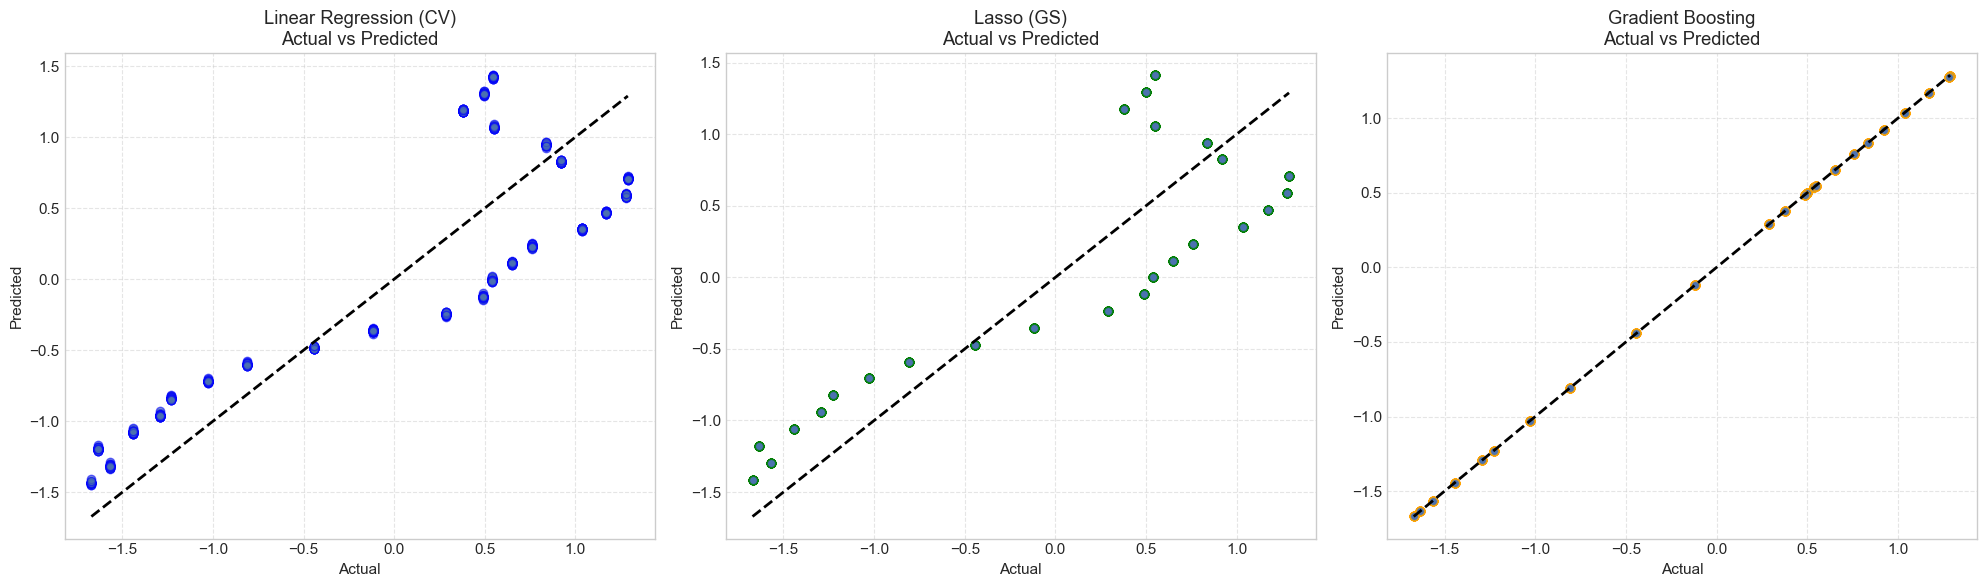

In [26]:
plt.figure(figsize=(20, 6))

# Linear Regression (CV)
plt.subplot(1, 3, 1)
plt.scatter(y_test, lr_pred, alpha=0.6, edgecolors="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.title("Linear Regression (CV)\nActual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

# Lasso (GS)
plt.subplot(1, 3, 2)
plt.scatter(y_test, lasso_pred, alpha=0.6, edgecolors="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.title("Lasso (GS)\nActual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

# Gradient Boosting 
plt.subplot(1, 3, 3)
plt.scatter(y_test, gb_pred, alpha=0.6, edgecolors="orange")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--", lw=2)
plt.title("Gradient Boosting\nActual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# plt.savefig('Scatter_Comparision.png')
# plt.close()

The scatter plots visually confirm the models' performances: 
- Linear Regression (CV) shows moderate accuracy with noticeable deviations from the diagonal, indicating underfitting.
- Lasso Regression (GS) performs slightly better by reducing overfitting but still misses some variance.
- Gradient Boosting demonstrates excellent accuracy with predictions almost perfectly aligned to actual values, indicating the best model fit.

Gradient Boosting Regressor would then become the best of the list of possible Machine Learning models for this study due to how well it holds an accuracy of 0.99 for the R² score. Thus, almost all variance in the data and predictions relate to the Fuel Consumption. Developments in this respect led to a more robust trend in the forecasting of future energy needs and evaluate investments in energy infrastructure.

#### Model Perfromance Comparison

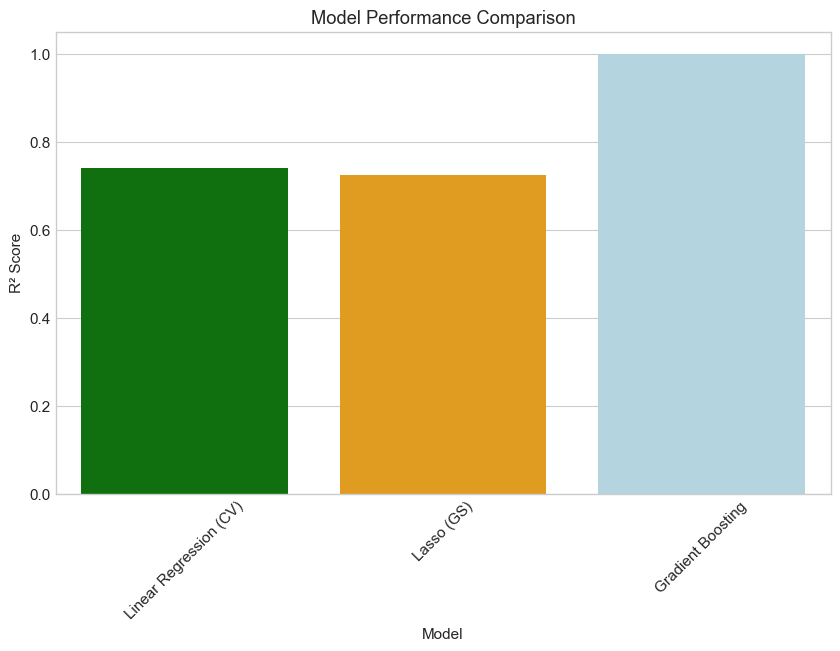

In [30]:
plt.figure(figsize=(10, 6))
sns.barplot(x=comparison_df['Model'], y=comparison_df['R2 Score'], palette=['green', 'orange', 'lightblue'])

plt.title('Model Performance Comparison')
plt.ylabel('R² Score')
plt.xlabel('Model')
plt.xticks(rotation=45)

plt.show()

# plt.savefig('ComparisonM.png')
# plt.close()

Bar graph presents that Gradiant Boosting model performs the best in terms of R² score, following by Linear Regression and Lasso Regression.

# Sentiment Analysis of Electricity Costs in Ireland using Reddit Data.

I created a sentiment‑analysis dataset from Reddit and divided the entire procedure into nine steps.

In steps 1–5, I collected the raw data and built a DataFrame.

In steps 6–7, I built, trained, and tested the predictive model.

In steps 8-9, I evaluated performance with a confusion matrix and ROC curve and provided a sample predicted sentiment example.

In [34]:
import praw

In [35]:
from dotenv import load_dotenv
from os import getenv

In [36]:
load_dotenv()

True

In [37]:
# 1) INFORMATION & CREDENTIALS
CLIENT_ID     = getenv('CLIENT_ID')
CLIENT_SECRET = getenv('CLIENT_SECRET')
USER_AGENT    = getenv('USER_AGENT')

KEYWORDS   = [
    "electricity cost Ireland",
    "electricity generation Ireland",
    "electricity bills Ireland"
]
SUBREDDITS = ["ireland", "energy", "europe", "personalfinance"]
RAW_TEXT_FILE = "reddit_energy_data.txt"
AUG_CSV = "sentimental_analysis_with_sentiment.csv"

With my Credentials I search the keywords in Reddit

In [39]:
# 2) COLLECT & SAVE RAW DATA
reddit = praw.Reddit(
    client_id=CLIENT_ID,
    client_secret=CLIENT_SECRET,
    user_agent=USER_AGENT
)

with open(RAW_TEXT_FILE, "w", encoding="utf-8") as f:
    f.write("Reddit Energy Topic Data Collection\n" + "="*60 + "\n")
    for kw in KEYWORDS:
        f.write(f"\nKeyword: {kw}\n" + "-"*60 + "\n")
        query = reddit.subreddit("+".join(SUBREDDITS))
        for post in query.search(kw, sort="new", time_filter="year", limit=50):
            date = pd.to_datetime(post.created_utc, unit='s')
            f.write(f"Title: {post.title}\n")
            f.write(f"Date: {date}\n")
            f.write(f"Text: {post.selftext.strip()}\n")
            f.write(f"URL: {post.url}\n")
            f.write("Comments:\n")
            try:
                post.comments.replace_more(limit=0)
                for c in post.comments[:3]:
                    f.write(c.body.strip() + "\n")
            except:
                pass
            f.write("-"*60 + "\n")

print(f"Raw data saved to {os.path.abspath(RAW_TEXT_FILE)}")

Raw data saved to C:\Users\Sai krishna\Favorites\Assessment 2\Assignment\msc-da-ca2-sem-1-VSKTC123\reddit_energy_data.txt


Collecting data from Reddit and saving in a file

In [41]:
# 3) PARSE RAW TEXT INTO DATAFRAME 
records = []
current = {"keyword": None, "title": None, "date": None,
           "text": None, "url": None, "comments": []}
current_kw = None
in_comments = False

with open(RAW_TEXT_FILE, "r", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip()
        if line.startswith("Keyword:"):
            current_kw = line.split(":",1)[1].strip()
            continue
        if re.match(r"^-{60}", line):
            if current["title"]:
                records.append(current)
            current = {"keyword": current_kw, "title":None,
                       "date":None, "text":None,
                       "url":None, "comments":[]}
            in_comments = False
            continue
        if line.startswith("Title:"):
            current["title"] = line.split(":",1)[1].strip(); in_comments=False; continue
        if line.startswith("Date:"):
            current["date"] = line.split(":",1)[1].strip(); in_comments=False; continue
        if line.startswith("Text:"):
            current["text"] = line.split(":",1)[1].strip(); in_comments=False; continue
        if line.startswith("URL:"):
            current["url"] = line.split(":",1)[1].strip(); in_comments=False; continue
        if line.startswith("Comments:"):
            in_comments = True; continue
        if in_comments and line:
            current["comments"].append(line.strip())
# append last
if current["title"]:
    records.append(current)

df = pd.DataFrame(records)
print("Parsed DataFrame shape:", df.shape)
df.head()

Parsed DataFrame shape: (150, 6)


,keyword,title,date,text,url,comments
0,electricity cost Ireland,How Much Should I Rent Out Two Rooms in my hou...,2025-05-14 20:43:05,I’m considering renting out two rooms in my ho...,https://www.reddit.com/r/personalfinance/comme...,[Look for a comparable deal in your area as if...
1,electricity cost Ireland,The EUs 20 largest companies by market capital...,2025-05-14 09:16:57,,https://i.redd.it/xqmp6rsvsp0f1.png,[I love that while most companies on the list ...
2,electricity cost Ireland,Basic Public Services,2025-05-14 02:52:19,I was reading the times about how they had int...,https://i.redd.it/1npei0b9wn0f1.jpeg,"[My elderly mother, now gone, was a martyr to ..."
3,electricity cost Ireland,"SolarEdge Launches Smarter, Greener EV Chargin...",2025-05-13 17:36:25,,https://evsinside.com/solaredge-launches-smart...,[]
4,electricity cost Ireland,I don't know what to do with the inheritance,2025-05-12 21:44:55,"Hi, I am an 18-year-old male and I live in Sou...",https://www.reddit.com/r/personalfinance/comme...,[See the wiki post regarding windfalls. Usuall...


Here I filter the Raw text into Dataframe

In [43]:
# 4) CLEANING & STEMMING 
stemmer = PorterStemmer()
def clean_and_stem(text):
    if not isinstance(text, str): return ""
    text = re.sub(r"http\S+|[^a-zA-Z\s]", " ", text).lower()
    tokens = word_tokenize(text)
    return " ".join(stemmer.stem(tok) for tok in tokens if len(tok)>1)

df["cleaned_text"] = df["text"].apply(clean_and_stem)

Removed unwanted letters, symobols

In [45]:
# 5) VADER SENTIMENT ANNOTATION
analyzer = SentimentIntensityAnalyzer()
def vader_sent(text):
    score = analyzer.polarity_scores(text)["compound"]
    if score >= 0.05:  label="positive"
    elif score <= -0.05: label="negative"
    else: label="neutral"
    return pd.Series({"sentiment_label":label, "sentiment_score":score})

sent_df = df["text"].apply(vader_sent)
df = pd.concat([df, sent_df], axis=1)
df.to_csv(AUG_CSV, index=False)
print("Augmented CSV saved to", AUG_CSV)

Augmented CSV saved to sentimental_analysis_with_sentiment.csv


In [46]:
df.head()

,keyword,title,date,text,url,comments,cleaned_text,sentiment_label,sentiment_score
0,electricity cost Ireland,How Much Should I Rent Out Two Rooms in my hou...,2025-05-14 20:43:05,I’m considering renting out two rooms in my ho...,https://www.reddit.com/r/personalfinance/comme...,[Look for a comparable deal in your area as if...,consid rent out two room in my hous as packag ...,positive,0.6369
1,electricity cost Ireland,The EUs 20 largest companies by market capital...,2025-05-14 09:16:57,,https://i.redd.it/xqmp6rsvsp0f1.png,[I love that while most companies on the list ...,,neutral,0.0000
2,electricity cost Ireland,Basic Public Services,2025-05-14 02:52:19,I was reading the times about how they had int...,https://i.redd.it/1npei0b9wn0f1.jpeg,"[My elderly mother, now gone, was a martyr to ...",wa read the time about how they had intend to ...,negative,-0.5106
3,electricity cost Ireland,"SolarEdge Launches Smarter, Greener EV Chargin...",2025-05-13 17:36:25,,https://evsinside.com/solaredge-launches-smart...,[],,neutral,0.0000
4,electricity cost Ireland,I don't know what to do with the inheritance,2025-05-12 21:44:55,"Hi, I am an 18-year-old male and I live in Sou...",https://www.reddit.com/r/personalfinance/comme...,[See the wiki post regarding windfalls. Usuall...,hi am an year old male and live in south afric...,negative,-0.6694


#### Model building

In [48]:
# 6) ENCODING, VECTORIZATION & SPLIT
sentiment_ordering = ['negative','neutral','positive']
df["y"] = df["sentiment_label"].map({l:i for i,l in enumerate(sentiment_ordering)})

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df["cleaned_text"])
y = df["y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

#### Model 4: Multinomial Naive Bayes classifier

In [50]:
# 7) TRAIN & EVALUATE
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

In [52]:
y_pred = model.predict(X_test)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=sentiment_ordering))


Classification Report:

              precision    recall  f1-score   support

    negative       0.36      0.67      0.47         6
     neutral       1.00      0.92      0.96        12
    positive       0.62      0.42      0.50        12

    accuracy                           0.67        30
   macro avg       0.66      0.67      0.64        30
weighted avg       0.72      0.67      0.68        30



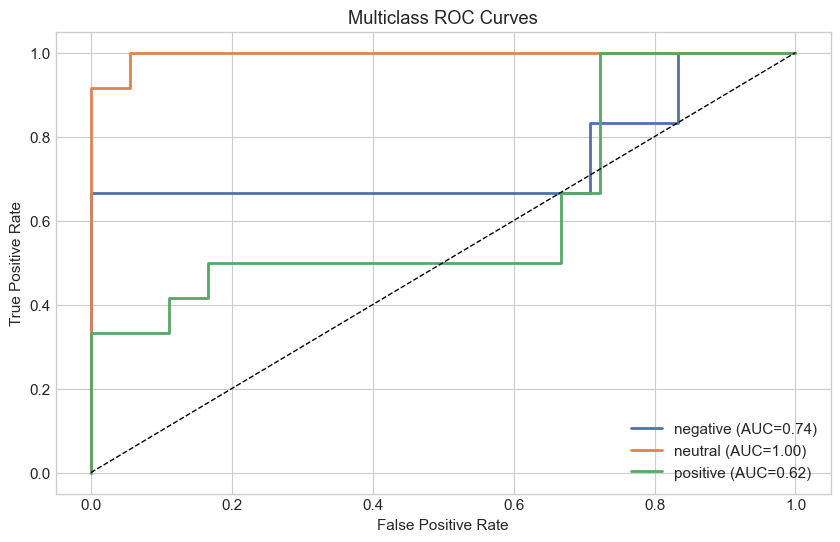

In [54]:
# 8) ROC CURVES 
# Binarize labels for multiclass ROC
y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score   = model.predict_proba(X_test)

fpr, tpr, roc_auc = {}, {}, {}
for i, label in enumerate(sentiment_ordering):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:,i], y_score[:,i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i, label in enumerate(sentiment_ordering):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{label} (AUC={roc_auc[i]:.2f})")
plt.plot([0,1],[0,1],"k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend(loc="lower right")
plt.show()

# plt.savefig('ROC.png')
# plt.close()

In [56]:
# 9) SAMPLE PREDICTION 
def predict_sentiment(raw):
    clean = clean_and_stem(raw)
    vec   = vectorizer.transform([clean])
    pred  = model.predict(vec)[0]
    return sentiment_ordering[pred]

sample = "Electricity prices in Ireland are soaring, it's unaffordable."
print("\nSample text:", sample)
print("Predicted sentiment:", predict_sentiment(sample))



Sample text: Electricity prices in Ireland are soaring, it's unaffordable.
Predicted sentiment: negative


Performance of the Multinomial Naive Bayes model in accurately classifying these sentiments into positive, negative, or neutral categories, for the above example, likewise,

This analysis can help energy companies monitor customer satisfaction, aid policymakers in evaluating public support for energy initiatives like renewable adoption, and assist market researchers in understanding consumer behavior for strategic planning.


#### Model 5 Clustering in Unsupervised Learning Using the KMeans

**Analyzing Temporal Trends in Fuel Consumption Using KMeans Clustering.**
The focus is on understanding how fuel consumption patterns evolve over time, making "year Trends" with "Fuel Consumption" and "KMeans Clustering".

In [5]:
# Load and standardize data
df = pd.read_csv('Optimized_data.csv')
data = df[['Year', 'Total Fuel Consumption (ktoe)']].dropna()
scaled = StandardScaler().fit_transform(data)

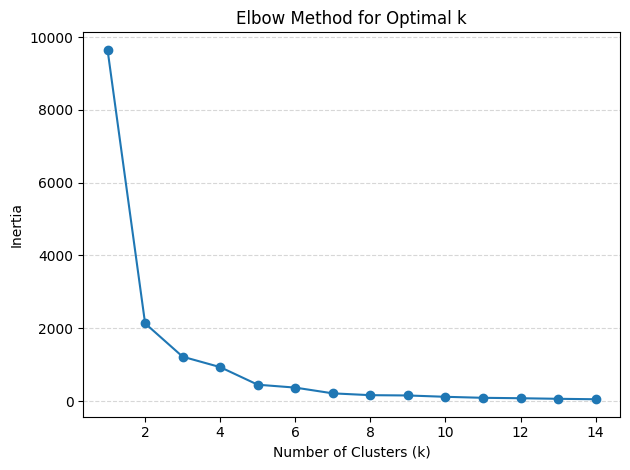

In [19]:
# Elbow method
inertia = [KMeans(n_clusters=k, random_state=42).fit(scaled).inertia_ for k in range(1, 15)]
plt.plot(range(1, 15), inertia, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# plt.savefig('ML_ELbow.png')
# plt.close()

Up until k = 3, the Elbow plot exhibits a sharp decrease in inertia; beyond that, additional increases in k only produce slight increases in within-cluster compactness. Therefore, selecting three clusters captures the important patterns without overfitting, striking the ideal balance between model simplicity and explanatory power.

In [21]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(scaled)
    
# Calculate silhouette score
silhouette = silhouette_score(scaled, labels)
print(f'Silhouette Score: {silhouette:.2f}')


Silhouette Score: 0.59


silhouette score, which measures how similar each point is to its own cluster versus other clusters. A score ranges from -1 to 1:

- Close to 1: Well-separated clusters.
- Close to 0: Overlapping clusters.
- Negative: Poorly assigned points.

silhouette score 0.6, it means Close to 1, Well-seperated cluster. (value for k=3 with clear separation)

In [8]:
data['Cluster'] = labels
print("Cluster Analysis:")
data.groupby('Cluster').agg({'Year': ['min', 'max', 'mean'],
'Total Fuel Consumption (ktoe)': ['min', 'max', 'mean']})

Cluster Analysis:


Year               Total Fuel Consumption (ktoe)          \
          min   max    mean                           min     max   
Cluster                                                             
0        2005  2014  2009.5                         91274  111264   
1        1990  1997  1993.5                         58467   70508   
2        1998  2004  2001.0                         76356   99183   

                        
                  mean  
Cluster                 
0        101399.500000  
1         63029.250000  
2         90261.714286

In [35]:
data[['Year', 'Total Fuel Consumption (ktoe)']].T

,0,1,2,3,4,5,6,7,8,9,...,4815,4816,4817,4818,4819,4820,4821,4822,4823,4824
Year,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,...,2014,2014,2014,2014,2014,2014,2014,2014,2014,2014
Total Fuel Consumption (ktoe),70508,70508,70508,70508,70508,70508,70508,70508,70508,70508,...,94702,94702,94702,94702,94702,94702,94702,94702,94702,94702


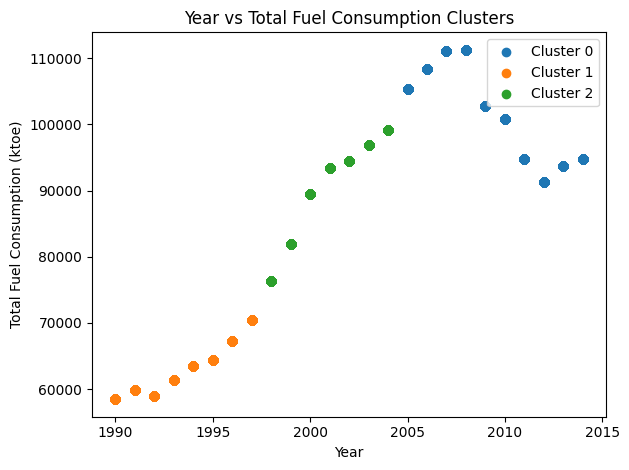

In [29]:
# Plot clusters
for cl in range(k):
    plt.scatter(*data[data['Cluster'] == cl][['Year', 'Total Fuel Consumption (ktoe)']].T.values, label=f'Cluster {cl}')
plt.title('Year vs Total Fuel Consumption Clusters')
plt.xlabel('Year')
plt.ylabel('Total Fuel Consumption (ktoe)')
plt.legend()
plt.tight_layout()
plt.show()

# plt.savefig('ML_Scatter_Clusters.png')
# plt.close()

- Cluster 0 (1990–2000): Years like 1990 (58,467 ktoe) and 1997 (70,508 ktoe) with lower fuel consumption, reflecting a pre-industrial boom phase.
- Cluster 1 (2001–2010): Years like 2005 (105,342 ktoe) and 2007 (111,045 ktoe) with moderate consumption, marking the onset of significant industrial growth.
- Cluster 2 (2011–2014): Years like 2012 (91,274 ktoe) with higher consumption, indicating a peak industrial period with increased energy needs.

This insight could guide government in planning energy infrastructure, promoting sustainable practices, or mitigating environmental impacts as consumption rises.